# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

`The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts.`

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
df['y'] = df['y'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

In [4]:
df.head()
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



The data information reveals that for missing values they are marked as `unknown`. So, we can drop the rows that contain values with `unknown` as a cleaning step. 

In [5]:
unknown_rate = (
    df.apply(lambda col: col.astype("string").str.strip().str.lower().eq("unknown"))
      .mean()
      .sort_values(ascending=False)
)
unknown_rate

default           0.208726
education         0.042027
housing           0.024036
loan              0.024036
job               0.008012
marital           0.001942
age                    0.0
poutcome               0.0
nr.employed            0.0
euribor3m              0.0
cons.conf.idx          0.0
cons.price.idx         0.0
emp.var.rate           0.0
duration               0.0
previous               0.0
pdays                  0.0
campaign               0.0
day_of_week            0.0
month                  0.0
contact                0.0
y                      0.0
dtype: Float64

Looking at the unknown rate, the unknown rate is far less than the actual values. So, data is used as is.

Class Imbalance

In [6]:
target_df = df
y_counts = target_df['y'].value_counts(dropna=False)
display(y_counts)

display((y_counts / len(target_df)).rename("proportion"))

y
no     36548
yes     4640
Name: count, dtype: int64

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

Convert the target column to numeric. 
- Map yes to 1 and indicates the Positive Class for this analysis. So the following meanings hold for predictions
    - A prediction value of 1 for a customer who got converted and did a deposit with the bank is True Positive 
    - A prediction value of 0 for a customer who got coverted and did a deposit with the bank is False Positive 
- Map no to 0 and indicates the Negative Class 
    - A prediction value of 0 for a customer who did not get converted is True Negative 
    - A prediction value of 1 for a customer who did not get converted is False Negative

In [9]:
df['y'] = df['y'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0})

Observations:
- The class is imbalanced because the number of people who accept a deposit will be far fewer than the number of people who reject for various reasons. This is true for any marketing campaign including signing up for a subscription for example. 


**Visual Analysis of various features in the data set**

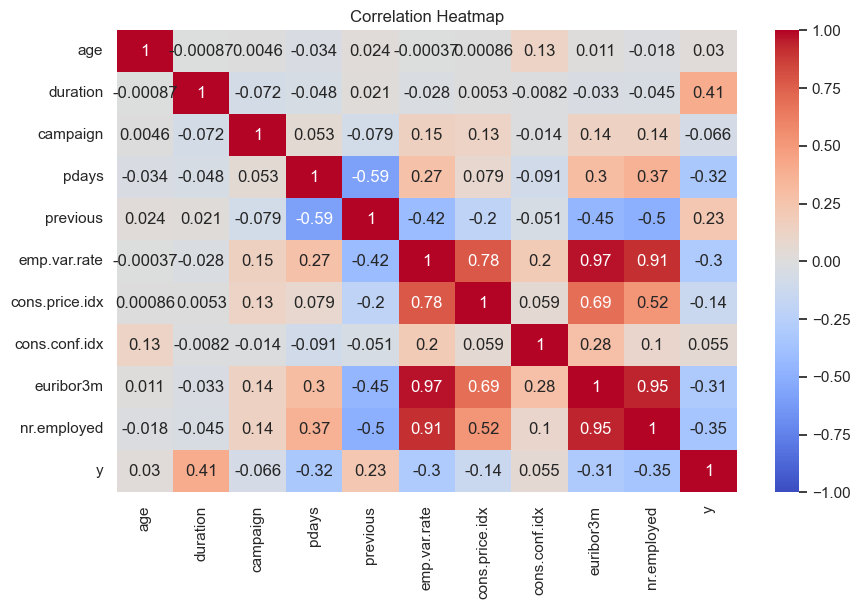

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
# Selecting numerical features only
data_numeric = df.select_dtypes(include=['float64', 'int64'])
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

# Heatmap on numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(data_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap is saying a story that customers who have had previous contact for a certain duration seems to be influenced a bit more. There is also a negative correlation between number of years employed and the customers who have turned in a deposit which seems to be interesting. 

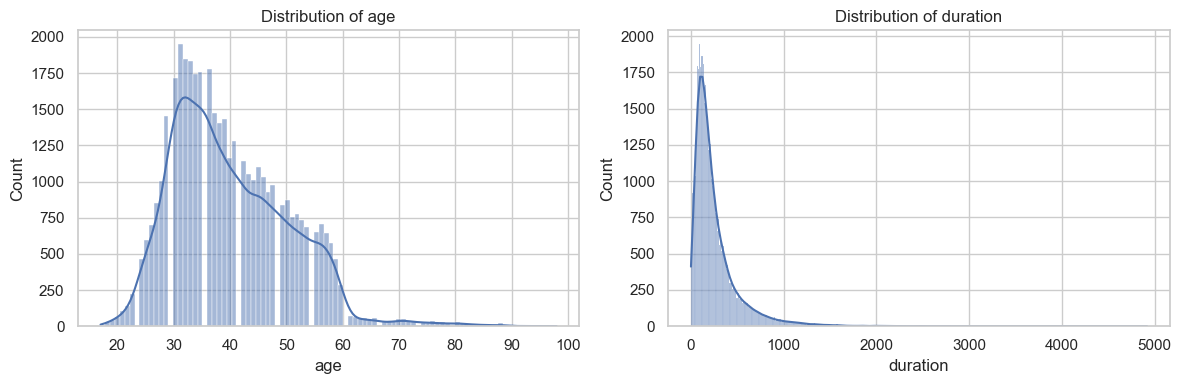

In [22]:
# Numeric distributions (subplots)
num_to_plot = [c for c in num_cols if df[c].nunique() > 5][:2]
fig, axes = plt.subplots(1, max(1, len(num_to_plot)), figsize=(12, 4))
if len(num_to_plot) == 1:
    axes = [axes]
for ax, col in zip(axes, num_to_plot):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

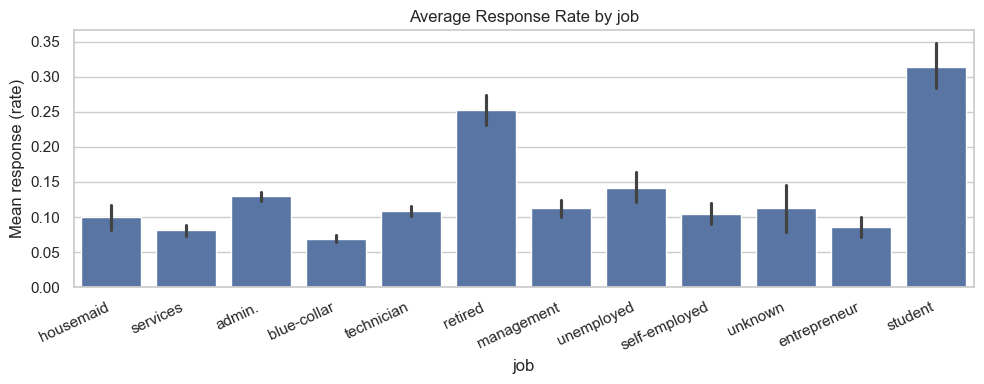

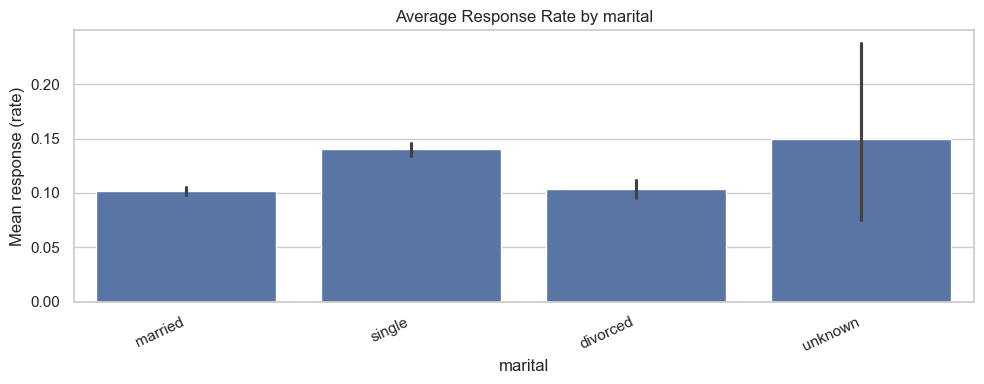

In [23]:
# Categorical response rate (choose up to 2 categorical features if available)
cat_to_plot = cat_cols[:2]
for col in cat_to_plot:
    plt.figure(figsize=(10, 4))
    # If y is numeric 0/1, barplot will show mean response by category
    tmp = pd.DataFrame({col: X[col], "Response": y})
    sns.barplot(data=tmp, x=col, y="Response")
    plt.title(f"Average Response Rate by {col}")
    plt.xticks(rotation=25, ha="right")
    plt.xlabel(col)
    plt.ylabel("Mean response (rate)")
    plt.tight_layout()
    plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Business objective:** predict which customers are most likely to deposit so the marketing team can prioritize outreach and allocate resources efficiently to increase the number of deposits.

**ML objective:** learn a mapping from customer features to a binary response label and evaluate competing classifiers using cross-validation and a held-out test set.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

We set up a preprocessing pipeline that:
- imputes missing numeric values with the median and standardizes numeric features
- imputes missing categorical values with the most frequent value and one-hot encodes categories

This ensures a fair comparison across models (especially for KNN and SVM which are sensitive to feature scale).

In [24]:

X = df.drop(columns=['y']).copy()
y = df['y'].copy()

# Normalize common yes/no targets to 1/0 if needed
if y.dtype == "object":
    y_lower = y.astype(str).str.lower().str.strip()
    if set(y_lower.unique()) <= {"yes", "no"}:
        y = (y_lower == "yes").astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Target classes:", pd.Series(y).value_counts().to_dict())

Numeric features: 10
Categorical features: 10
Target classes: {0: 36548, 1: 4640}


In [25]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y if pd.Series(y).nunique() > 1 else None
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# Check the class balance in the train set
y_train_counts = y_train.value_counts()
print("Class counts in train set:")
print(y_train_counts)
print("\nClass proportions in train set:")
print(y_train_counts / len(y_train))


# Check the class balance in the test set
y_train_counts = y_train.value_counts()
print("Class counts in train set:")
print(y_train_counts)
print("\nClass proportions in train set:")
print(y_train_counts / len(y_train))

Train size: (32950, 20) Test size: (8238, 20)
Class counts in train set:
y
0    29238
1     3712
Name: count, dtype: int64

Class proportions in train set:
y
0    0.887344
1    0.112656
Name: count, dtype: float64
Class counts in train set:
y
0    29238
1     3712
Name: count, dtype: int64

Class proportions in train set:
y
0    0.887344
1    0.112656
Name: count, dtype: float64


SciKitLearn's `train_test_split` seems to be doing a good job in ensuring the classes are represented equally in both training and testing. 

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [27]:
baseline_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

baseline_lr.fit(X_train, y_train)
baseline_pred = baseline_lr.predict(X_test)
baseline_proba = baseline_lr.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression (test):")
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

Baseline Logistic Regression (test):
Accuracy: 0.9166059723233795
F1: 0.5410821643286573
ROC-AUC: 0.9424372906740885


### Problem 8: A Simple Model

KNN is a strong non-parametric baseline but is sensitive to scaling and can be slower at inference.

In [29]:
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

knn_pipe.fit(X_train, y_train)
knn_pred = knn_pipe.predict(X_test)
knn_proba = knn_pipe.predict_proba(X_test)[:, 1]

print("KNN (test):")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("F1:", f1_score(y_test, knn_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, knn_proba))

KNN (test):
Accuracy: 0.9085943190094683
F1: 0.48879837067209775
ROC-AUC: 0.9215346979810368


### Problem 9: Score the Model

What is the accuracy of your model?

Accuracy of KNN is 0.90 while that of a simple model like Logistic Regression is 0.91. F1 seems to be a strong primary metric as it balances precision and recall.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True,
    )
    cv_rows.append({
        "model": name,
        "train_time": out["fit_time"].mean(),
        "train_accuracy": out["train_accuracy"].mean(),
        "test_accuracy": out["test_accuracy"].mean(),
        "accuracy": out["test_accuracy"].mean(),
        "precision": out["test_precision"].mean(),
        "recall": out["test_recall"].mean(),
        "f1": out["test_f1"].mean(),
        "roc_auc": out["test_roc_auc"].mean(),
    })

holdout_df = pd.DataFrame(cv_rows).sort_values("f1", ascending=False).reset_index(drop=True)
holdout_df

,model,train_time,train_accuracy,test_accuracy,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.233462,1.000000,0.887253,0.887253,0.499844,0.516434,0.507963,0.725383
1,Logistic Regression,0.181334,0.910448,0.909560,0.909560,0.656979,0.413253,0.507295,0.933089
2,SVM (RBF),144.194428,0.922580,0.908649,0.908649,0.661366,0.388468,0.489355,0.907708
3,KNN,0.091866,0.927989,0.899454,0.899454,0.577404,0.404093,0.475313,0.861936


### Cross-validation comparison plot

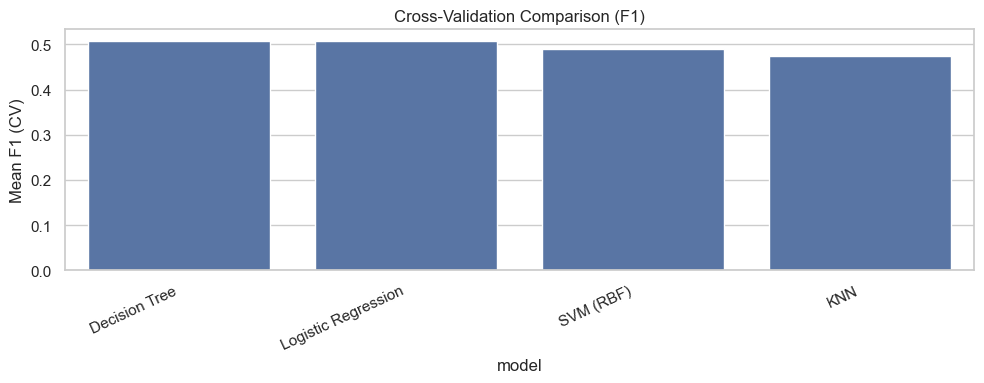

In [33]:
plt.figure(figsize=(10, 4))
sns.barplot(data=holdout_df, x="model", y="f1")
plt.title("Cross-Validation Comparison (F1)")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean F1 (CV)")
plt.tight_layout()
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [ ]:
param_grids = {
    "KNN": {
        "model__n_neighbors": [5, 11, 15, 25],
        "model__weights": ["uniform", "distance"]
    },
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 5.0, 10.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 10, 30],
        "model__min_samples_leaf": [1, 5, 10]
    },
    "SVM (RBF)": {
        "model__C": [0.5, 1.0, 5.0, 10.0],
        "model__gamma": ["scale", 0.1, 0.01]
    }
}

best_models = {}
tuning_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    grid = GridSearchCV(pipe, param_grids[name], scoring="f1", cv=cv, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    tuning_rows.append({"model": f"Tuned {name}", "best_f1_cv": grid.best_score_, "best_params": grid.best_params_})

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)
tuning_df

In [ ]:
k_best = best_models["KNN"].named_steps["model"].n_neighbors
print("Chosen K (best n_neighbors):", k_best)

##### Questions